In [5]:
from data_loader import get_graph_nodes
from main import load_graph_and_communities
from removal import inverse_communities

# Node-labeled: contact-high-school, contact-primary-school
# Edge-labeled: Algebra, Geometry, Music-Rev, Restaurants-Rev, Bars-Rev

ds = ["contact-high-school", "contact-primary-school", "Algebra", "Geometry", "Music-Rev", "Restaurants-Rev", "Bars-Rev"]
for d  in ds:
    for tau in [0, 2, None]:
        graph, communities = load_graph_and_communities(d, tau=tau, verbose=True)
        if not communities: continue
        inv_comm = inverse_communities(communities)
        inter_comm_hedges = set()
        for hedge, nodes in graph.items():
            unique_communities = set()
            unique_communities.update([inv_comm.get(node, "UNK") for node in nodes])
            if "UNK" in unique_communities:
                continue
                # raise ValueError("node has no recorded community")
            if len(unique_communities) > 1:
                inter_comm_hedges.add(hedge)

        M = len(graph)
        # print(f"{len(inter_comm_hedges)/M}")

        print(f"dataset: {d}, tau: {tau}, inter_comm_percentage: {len(inter_comm_hedges)/M}")


[warn] missing CD labels for tau=1: data/labeled/contact-high-school\cd_t1_labels.txt
Loaded dataset 'contact-high-school' (node-labeled) with 7818 hyperedges and 0 communities
Loaded dataset 'contact-high-school' (node-labeled) with 7818 hyperedges and 8 communities
  communities sizes: min=33, max=67, avg=40.875
dataset: contact-high-school, tau: 2, inter_comm_percentage: 0.24827321565617805
Loaded dataset 'contact-high-school' (node-labeled) with 7818 hyperedges and 9 communities
  communities sizes: min=29, max=44, avg=36.333
dataset: contact-high-school, tau: None, inter_comm_percentage: 0.8635200818623688
[warn] missing CD labels for tau=1: data/labeled/contact-primary-school\cd_t1_labels.txt
Loaded dataset 'contact-primary-school' (node-labeled) with 12704 hyperedges and 0 communities
Loaded dataset 'contact-primary-school' (node-labeled) with 12704 hyperedges and 6 communities
  communities sizes: min=24, max=51, avg=40.333
dataset: contact-primary-school, tau: 2, inter_comm_pe

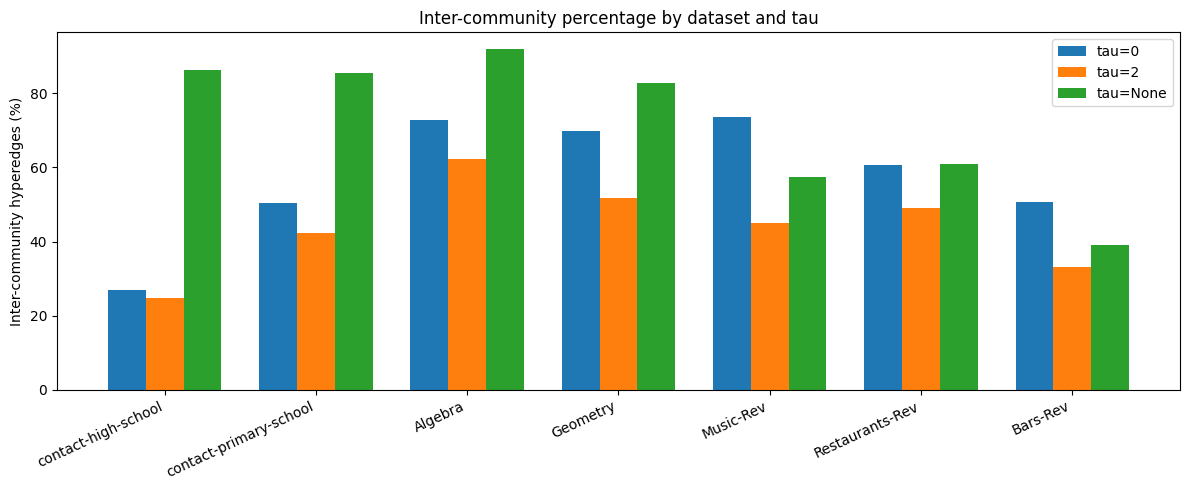

In [9]:
import matplotlib.pyplot as plt

# Recompute percentages into a structure we can plot
rows = []
for d in ds:
    for tau in [0, 2, None]:
        graph, communities = load_graph_and_communities(d, tau=tau, verbose=False)
        if not communities:
            continue

        inv_comm = inverse_communities(communities)
        inter_comm_hedges = set()
        for hedge, nodes in graph.items():
            unique_communities = {inv_comm.get(node, "UNK") for node in nodes}
            if "UNK" in unique_communities:
                continue
            if len(unique_communities) > 1:
                inter_comm_hedges.add(hedge)

        M = len(graph)
        pct = 100.0 * len(inter_comm_hedges) / M if M else 0.0
        tau_label = "None" if tau is None else str(tau)
        rows.append((d, tau_label, pct))

# Grouped bar chart: one group per dataset, bars for tau in {1,2,all}
datasets = list(dict.fromkeys([r[0] for r in rows]))
tau_order = ["0", "2", "None"]
values = {d: {t: 0.0 for t in tau_order} for d in datasets}
for d, t, p in rows:
    values[d][t] = p

x = list(range(len(datasets)))
width = 0.25
offsets = {"0": -width, "2": 0.0, "None": width}

plt.figure(figsize=(12, 5))
for t in tau_order:
    y = [values[d][t] for d in datasets]
    plt.bar([i + offsets[t] for i in x], y, width=width, label=f"tau={t}")

plt.xticks(x, datasets, rotation=25, ha="right")
plt.ylabel("Inter-community hyperedges (%)")
plt.title("Inter-community percentage by dataset and tau")
plt.legend()
plt.tight_layout()
plt.show()